In [1]:
import importlib as il
import numpy as np
import more_itertools as mit
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import scipy.linalg as spl
import linetimer as lt

import gurobipy as gp

import gurobi_utils as gu
import dikin_utils as du
import plot_utils as pu

import example_loader as el
import miplib_loader as ml
import jsplib_loader as jl

status_lookup = {getattr(gp.GRB.Status, k): k for k in gp.GRB.Status.__dir__() if "A" <= k[0] <= "Z"}

%matplotlib inline
env = gp.Env(empty=True)
env.setParam("OutputFlag", 0)
env.start()

<gurobipy.Env, Parameter changes: WLSAccessID=(user-defined), WLSSecret=(user-defined), LicenseID=2586148, OutputFlag=0>

What we want to do here:
1. Find an LP optimum for some problem.
2. Back away from that optimum into the interior sqrt(n)/2 distance.
3. Find the eigenvectors for Dikin's H at that point.
4. Round those to be integer values.
5. Run the LLL reduction on that result.
6. Make that be unimodular if it's not.
7. Transform the original problem and run the MIP solver for it.

In [2]:
def retreat_from_optimum_via_average_vector(V: np.ndarray, x: np.ndarray, target_distance):
    """Retreat from the optimum by moving in the direction of the average vector."""
    # this isn't perfect at the moment in that we should normalize the columns of V first.
    # that way each vector would contribute equally to the average.
    # however, some columns are zero-length, and we would have to handle that case.
    
    # normalize the columns first so that they all contribute equally:
    V /= np.linalg.norm(V, axis=0)

    avg = np.mean(V, axis=1)
    nrm = np.linalg.norm(avg) + 1e-5
    return x - avg * target_distance / nrm

def find_corner(relaxed: gp.Model, int_vars, int_var_idx):
    basis = gu.read_basis(relaxed)
    tableau, col_to_var_idx, negated_rows = gu.read_tableau(relaxed, basis, extra_rows=0)
    negated_vars = [basis[nr] for nr in negated_rows]

    # the current understanding (from nlhdlr_quadratic.c in SCIP): 
    # negate all columns with variables at status -1
    # and negate all columns match slack variables of type <
    variables = relaxed.getVars()
    constraints = relaxed.getConstrs()
    for col, j in enumerate(col_to_var_idx):
        if j < len(variables):
            # print("Var INFO:", variables[j].VarName, "VBasis", variables[j].VBasis, "LB", variables[j].LB, "UB", variables[j].UB)
            if variables[j].VBasis == -2:
                # tableau[:, col] = variables[j].UB - tableau[:, col]
                tableau[:, col] = -tableau[:, col]
                print("   VBasis at -2 for", variables[j].VarName, variables[j].UB)
    #         if variables[j].VBasis == -1:  # not sure what to do with VBasis=-3
    #             tableau[:, col] = -tableau[:, col]  # variables[j].LB
    #             if variables[j].LB != 0.0:
    #                 print("Warning: LB is nonzero for variable", variables[j].VarName, "LB", variables[j].LB, "UB", variables[j].UB)
        else:
            constraint = constraints[j - len(variables)]
    #         # this might not be right: scip has status and tests for A_i*x being at lower or upper bound
    #         # if np.isclose(constraint.Slack, 0.0, atol=tol):
    #         #     tableau[:, col] = -tableau[:, col]
            if constraint.Sense == '>':  # Achterberg said lt and lte are standard; should just need to flip gt
                tableau[:, col] = -tableau[:, col]
                print("   GTE Constraint found for", constraint.ConstrName)

    # drop the rows of non-integer variables:
    to_drop = [i for i, b in enumerate(basis) if b not in int_var_idx]
    tableau = np.delete(tableau, to_drop, axis=0)  # TODO: don't even bother to read them in
    basis = np.delete(basis, to_drop) # update basis to match tableau

    # we want all the integer variables in order, assuming x, y as the first two.
    # however, some integer variables may be columns in the tableau, which is problematic.

    basis, tableau = mit.sort_together([basis, tableau], key_list=[0]) #, key=int_var_idx.get)
    tableau = np.array(tableau)

    sv = [int_vars[int_var_idx[b]].X for b in basis]
    return tableau, np.array(sv)

def make_primal_dual_values(mdl: gp.Model):
    """Extract primal and dual values from the model."""
    primal = np.array([v.X for v in mdl.getVars()])
    dual_cons = np.array([c.Pi for c in mdl.getConstrs()])
    # dual_vars = np.array([v.RC for v in mdl.getVars()])
    return primal, dual_cons

def get_A_b_c_l_u(mdl: gp.Model):
    mdl.update()
    A = mdl.getA()
    b = np.array(mdl.getAttr("RHS")).reshape(-1, 1)
    c = np.array(mdl.getAttr("Obj"))
    l = np.array(mdl.getAttr("LB"))
    u = np.array(mdl.getAttr("UB"))
    return A, b, c, l , u



In [8]:
import cvxpy as cp

def find_interior_point(old_model: gp.Model, distance, x0):
    old_model.update()
    r = cp.Variable(name="r", nonneg=True)
    new_vars = cp.Variable(old_model.NumVars, name="x")
    new_cons = []
    for i, v in enumerate(old_model.getVars()):
        ub = 1 if v.VType == 'B' else v.UB
        if ub < gp.GRB.INFINITY:
            new_cons.append(new_vars[i] + r <= ub)
        if v.LB > -gp.GRB.INFINITY: 
            new_cons.append(new_vars[i] - r >= v.LB)

    for constr in old_model.getConstrs():
        lhs_expr = old_model.getRow(constr)  # Get linear expression
        rhs_value = constr.RHS  # Get right-hand side
        sense = constr.Sense  # Get constraint type

        # Convert LHS to a CVXPY expression
        lhs_cvxpy = sum(lhs_expr.getCoeff(i) * new_vars[lhs_expr.getVar(i).index]
                        for i in range(lhs_expr.size()))
        
        multiplier = np.linalg.norm([lhs_expr.getCoeff(i) for i in range(lhs_expr.size())], 2)

        # Convert Gurobi sense to CVXPY constraint
        if sense == gp.GRB.LESS_EQUAL:
            new_cons.append(lhs_cvxpy + r * multiplier <= rhs_value)
        elif sense == gp.GRB.GREATER_EQUAL:
            new_cons.append(lhs_cvxpy - r * multiplier >= rhs_value)
        elif sense == gp.GRB.EQUAL:
            new_cons.append(lhs_cvxpy == rhs_value)

    new_cons.append(cp.sum_squares(new_vars - x0) <= distance ** 2)
    new_model = cp.Problem(cp.Maximize(r), new_cons)
    new_model.solve(solver=cp.GUROBI, verbose=False)

    if new_model.status == cp.OPTIMAL:
        x1 = new_vars.value
        r = r.value
        print("Interior point found:", x1, "r", r)
        return x1
    
    return None


(CVXPY) May 22 11:09:26 PM: Encountered unexpected exception importing solver GLOP:
RuntimeError('Unrecognized new version of ortools (9.12.4544). Expected < 9.12.0. Please open a feature request on cvxpy to enable support for this version.')
(CVXPY) May 22 11:09:26 PM: Encountered unexpected exception importing solver PDLP:
RuntimeError('Unrecognized new version of ortools (9.12.4544). Expected < 9.12.0. Please open a feature request on cvxpy to enable support for this version.')


Running: 2D from bottom
   Relaxed 2 variables on 2D from bottom
Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2586148
Academic license 2586148 - for non-commercial use only - registered to br___@vt.edu
Interior point found: [1.16648094 1.77040099] r 0.3586382369906304
Code block 'Finding interior point' took: 35.24349 ms
   Negated 0 constraints on 2D from bottom
   Retreat to: [1.16648094 1.77040099]
Running: 2D no easy cut from bottom
   Relaxed 2 variables on 2D no easy cut from bottom
Interior point found: [3.00222615 2.30504145] r 0.48491029134585595
Code block 'Finding interior point' took: 11.79853 ms
   Negated 0 constraints on 2D no easy cut from bottom
   Retreat to: [3.00222615 2.30504145]
Running: 2D steep from bottom
   Relaxed 2 variables on 2D steep from bottom
Interior point found: [2.68157671 3.0953952 ] r 0.5649323402361517
Code block 'Finding interior point' took: 11.27532 ms
   Negated 0 constraints on 2D steep from bottom
   Re

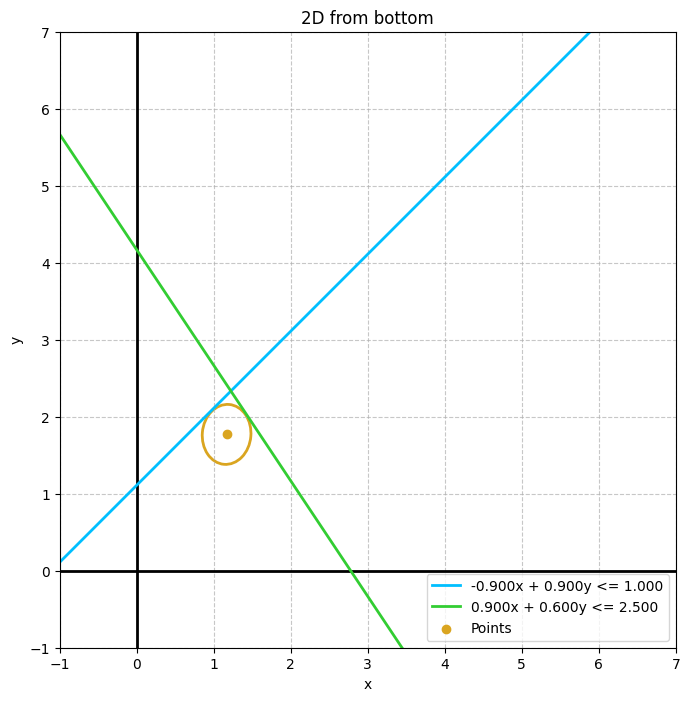

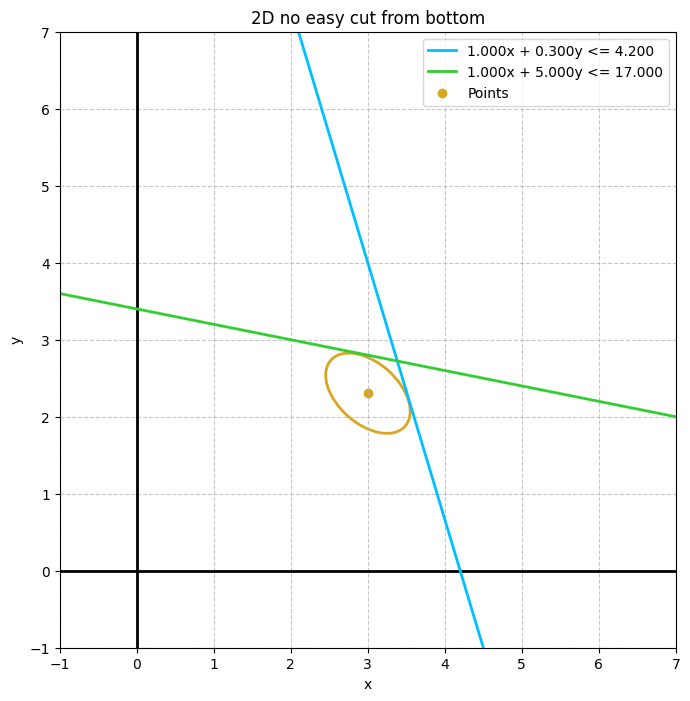

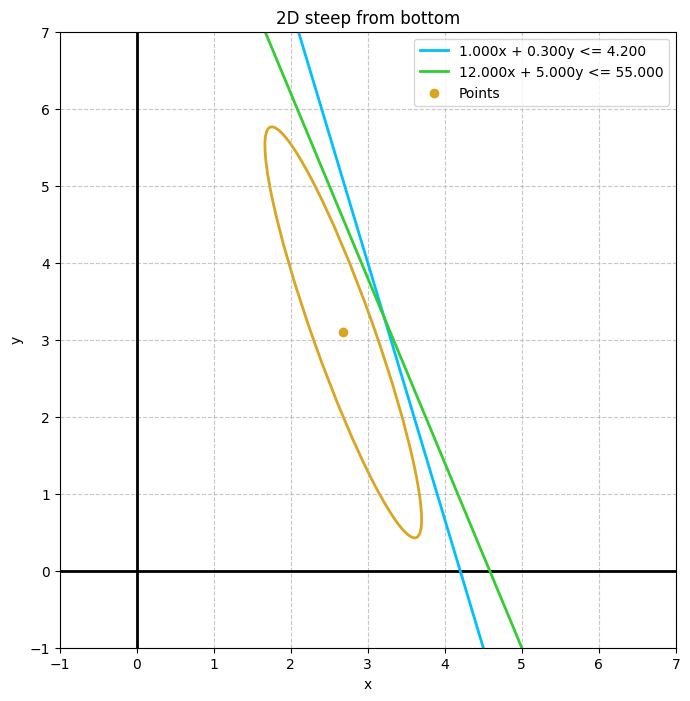

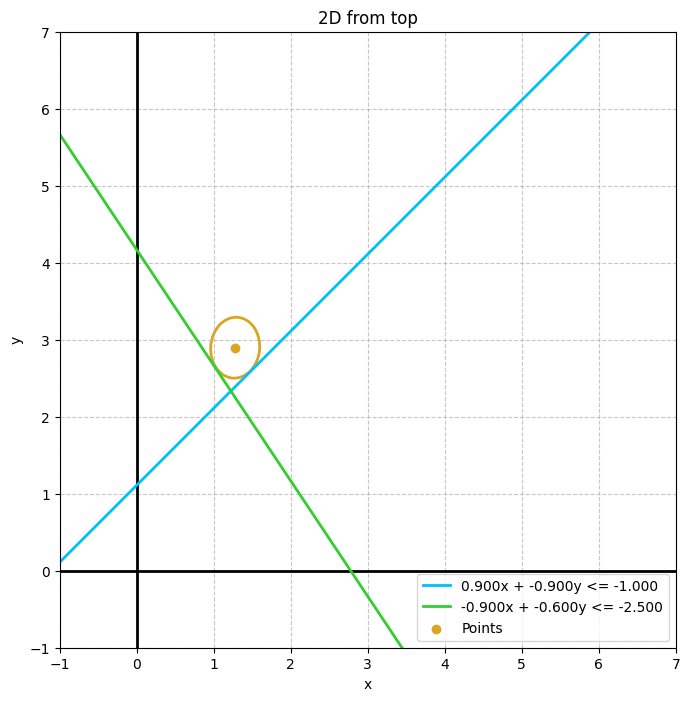

In [9]:
il.reload(el)
il.reload(gu)
il.reload(pu)
il.reload(du)

def relax_and_shrink(mdl: gp.Model, diagonal_distance, percent_of_diagonal):
    mdl.update()
    relaxed = mdl.copy()
    if relaxed.NumIntVars > 0:
        _, _ = gu.relax_int_or_bin_to_continuous(relaxed)
    relaxed.update()
    if percent_of_diagonal == 0.0:
        return relaxed
    
    for v in relaxed.getVars():
        if v.UB - v.LB < percent_of_diagonal * 2.0:
            gap = (v.UB - v.LB) * percent_of_diagonal
            v.LB += gap
            v.UB -= gap
        else:
            if v.LB > -gp.GRB.INFINITY:
                v.LB += percent_of_diagonal
            if v.UB < gp.GRB.INFINITY:
                v.UB -= percent_of_diagonal

    distance = diagonal_distance * percent_of_diagonal
    for c in relaxed.getConstrs():
        lhs = relaxed.getRow(c)
        coeffs = np.array([lhs.getCoeff(i) for i in range(lhs.size())])
        if c.Sense == '<':
            c.RHS -= distance * np.linalg.norm(coeffs) / lhs.size()
        elif c.Sense == '>':
            c.RHS += distance * np.linalg.norm(coeffs) / lhs.size()
    relaxed.update()
    return relaxed

instances = el.get_instances(env)
for instance in list(instances.values())[0:4]:
    model = instance.as_gurobi_model()
    model.update()
    print("Running:", model.ModelName)
    niv = model.NumIntVars
    _, _ = gu.relax_int_or_bin_to_continuous(model)
    model.optimize()
    x1 = np.array([v.X for v in model.getVars()])
    
    with lt.CodeTimer("Finding interior point"):
        x2 = find_interior_point(model, np.sqrt(niv) * 0.4, x1)    # shrunk = relax_and_shrink(model, np.sqrt(niv), 0.45)
    # shrunk.optimize()
    # x2 = np.array([v.X for v in shrunk.getVars()])
    # V, x = find_corner(model, int_vars, int_var_idx)
    # x2 = retreat_from_optimum_via_average_vector(V, x, np.sqrt(int_vars.size) * 0.4)
    # x, y = make_primal_dual_values(model)
    gu.standardize_gt_to_lt(model)
    A, b, c, lb, ub = get_A_b_c_l_u(model)
    # x2, its = du.least_squares_interior(A, b, x, l, u, d=np.sqrt(int_vars.size) * 0.4, infinity=gp.GRB.INFINITY)
    # x2, its = du.reverse_interior_point_gpt2(A, b, c, l, u, x, y, target_distance=np.sqrt(int_vars.size) * 0.4,
    #                                          infinity=10, is_maximizing=model.ModelSense == gp.GRB.MAXIMIZE)
    print("   Retreat to:", x2)
    senses = np.array(model.getAttr("Sense"))
    fig = pu.plot_constraints_lte(model.ModelName, A, b, lb, ub, senses, points=[x2[:2]])
    du.plot_ellipse(A, b, lb, ub, x2, fig=fig)

    # gu.standardize_gt_to_lt(copy)
    # A, b, c, l, u = get_A_b_c_l_u(copy)
    # fig = pu.plot_constraints_lte(model.ModelName, A, b, l, u, points=[x2[:2]], fig=fig)


    # could assert x2 is feasible




In [2]:
il.reload(du)
# test = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
# test = np.array([[1, -1, 3], [1, 0, 5], [1, 2, 6]], dtype=np.int64)
test = np.array([[1, 1, 1], [-1, 0, 2], [3, 5, 6]], dtype=np.int64)
# H = np.array([[30, 7], [9, 10]])
# test = np.array([[1, 0, 5], [1, -1, 3], [1, 2, 6]])


# B = du.lll_grok(test, delta=0.75)
# B, np.linalg.det(B), np.linalg.det(test)

import ntl_wrapper as ntl
ntl.lll(test)
test

# U = du.CLLL_Post(H)
# import scipy.sparse as sps
# test = sps.csc_matrix(test)
# U = du.CLLL_Post(test)
# H, U, np.linalg.det(U)

TypeError: lll(): incompatible function arguments. The following argument types are supported:
    1. (arg0: numpy.ndarray[numpy.int64], arg1: int, arg2: int) -> tuple[int, int, numpy.ndarray[numpy.int64]]

Invoked with: array([[ 1,  1,  1],
       [-1,  0,  2],
       [ 3,  5,  6]])

In [6]:
import ntl_wrapper as ntl
def generate_random_integer_matrix(size, value_range=20):
    while True:
        B = np.random.randint(-value_range, value_range+1, size=size)
        if np.linalg.matrix_rank(B) == min(size):
            return B

def gram_schmidt(B):
    n = B.shape[0]
    B_star = np.zeros_like(B, dtype=np.float64)
    mu = np.zeros((n, n))
    for i in range(n):
        B_star[i] = B[i]
        for j in range(i):
            mu[i, j] = np.dot(B[i], B_star[j]) / np.dot(B_star[j], B_star[j])
            B_star[i] -= mu[i, j] * B_star[j]
    return B_star, mu

def is_lll_reduced(B, delta=0.75):
    B_star, mu = gram_schmidt(B)
    n = B.shape[0]

    # Size reduction: |mu[i,j]| <= 0.5 for all j < i
    for i in range(1, n):
        for j in range(i):
            if abs(mu[i, j]) > 0.5 + 1e-8:
                return False

    # Lovász condition
    for k in range(n - 1):
        lhs = delta * np.dot(B_star[k], B_star[k])
        rhs = np.dot(B_star[k + 1] + mu[k + 1, k] * B_star[k], B_star[k + 1] + mu[k + 1, k] * B_star[k])
        if lhs > rhs + 1e-8:
            return False

    return True

def is_same_lattice(B1, B2):
    # Check if they span the same lattice by comparing Gram matrix volumes
    vol1 = np.sqrt(np.abs(np.linalg.det(np.dot(B1, B1.T))))
    vol2 = np.sqrt(np.abs(np.linalg.det(np.dot(B2, B2.T))))
    return np.allclose(vol1, vol2, atol=1e-5)

def in_lattice(B_basis, v):
    # Solve integer linear system Bx = v, and check if x is integer
    x, residuals, rank, s = np.linalg.lstsq(B_basis.T, v.T, rcond=None)
    return np.allclose(x, np.round(x))

def same_lattice_span(B, B_reduced):
    return all(in_lattice(B, row) for row in B_reduced)

def test_lll_reduce(lll_reduce_func, n=4, trials=10):
    for i in range(trials):
        print(f"\n--- Trial {i + 1} ---")
        B = generate_random_integer_matrix(n)
        print("Original basis:\n", B)

        B_reduced = B.copy()
        rank, det, U = lll_reduce_func(B_reduced, 3, 4)

        print("Reduced basis:\n", B_reduced)

        if not np.allclose(U @ B, B_reduced):
            print("❌ U * B != B_reduced")
            continue

        if rank != min(B.shape):
            print("❌ LLL reduction failed to produce a full-rank basis.")
            continue

        if U.shape[0] == U.shape[1] and round(np.linalg.det(U)) not in (1, 0, -1):
            print("❌ U is not unimodular. Det:", np.linalg.det(U))
            continue

        # if det not in (1, 0, -1):
        #     print("❌ Returned determinant of U is not 1, 0, or -1.")
        #     continue
        print("Determinant of B_reduced:", det)

        if not is_same_lattice(B, B_reduced):
            print("❌ Reduced basis does not span the same lattice.")
            continue

        if not is_lll_reduced(B_reduced):
            print("❌ Reduced basis does not satisfy LLL conditions.")
            continue

        print("✅ Passed all checks.")

test_lll_reduce(ntl.lll, n=(5,4), trials=5)



--- Trial 1 ---
Original basis:
 [[-19 -14   0  -8]
 [-19  -4  13 -14]
 [  0   8  -7   9]
 [ 17 -19  -3   7]
 [-15 -20   2 -19]]
Reduced basis:
 [[0 0 0 0]
 [0 1 0 0]
 [0 0 1 0]
 [0 0 0 1]
 [1 0 0 0]]
Determinant of B_reduced: 1
❌ Reduced basis does not span the same lattice.

--- Trial 2 ---
Original basis:
 [[ 20  16  12  -9]
 [ -8 -16  17  10]
 [-13  -1   9 -14]
 [  0  16 -17  15]
 [ 19 -15  20  -6]]
Reduced basis:
 [[ 0  0  0  0]
 [ 0  0  0 -1]
 [ 0  0  1  0]
 [ 1 -1  0  0]
 [-1 -1  0  0]]
Determinant of B_reduced: 4
✅ Passed all checks.

--- Trial 3 ---
Original basis:
 [[ 11  -1  -5  10]
 [ 18  -5  -2   6]
 [  9 -18 -15 -20]
 [ 12  14  -4 -13]
 [ -3   1 -19   9]]
Reduced basis:
 [[ 0  0  0  0]
 [ 0  0  0  1]
 [ 0  1  0  0]
 [-1  0 -1  0]
 [ 2  0 -2  0]]
Determinant of B_reduced: 16
✅ Passed all checks.

--- Trial 4 ---
Original basis:
 [[  3  18 -19   5]
 [ 15 -13  -2  10]
 [-20  -9 -16 -13]
 [  3   6   8   6]
 [-10  -8  15   6]]
Reduced basis:
 [[ 0  0  0  0]
 [ 1  0  0  0]
 [ 

/tmp/ipykernel_36786/2371937724.py:15: RuntimeWarning: invalid value encountered in scalar divide
  mu[i, j] = np.dot(B[i], B_star[j]) / np.dot(B_star[j], B_star[j])


$$
H(x_0) = A^\top W(x_0) A + D(x_0),
$$
where:

1. $( W(x_0) )$ is a diagonal weight matrix for the inequality constraints $( Ax \leq b )$, defined as:
$$
W(x_0) = \text{diag}\left(\frac{1}{(b_i - A_i^\top x_0)^2}\right), \quad i = 1, 2, \dots, m.
$$
Here, $( b_i - A_i^\top x_0 > 0 )$ because $( x_0 )$ is an interior point.

2. $( D(x_0) )$ is a diagonal matrix that accounts for the bounds $( l \leq x \leq u )$, defined as:
$$
D(x_0) = \text{diag}\left( \frac{1}{(x_{0j} - l_j)^2} + \frac{1}{(u_j - x_{0j})^2} \right), \quad j = 1, 2, \dots, n.
$$
The terms $( x_{0j} - l_j > 0 )$ and $( u_j - x_{0j} > 0 )$ hold because $( x_0 )$ is an interior point.

For the transformation, define $x=Uy + x_0$. Then:

The variable bounds transformation: $U^{-1} (\ell_x - x_0) \leq y \leq U^{-1} (u_x - x_0)$

Constraints: $A U y \leq b - A x_0$

Objective: $(c^T U) y + c^T x_0 + c_0 = (U^T c)^T y + c^T x_0 + c_0$

In [3]:
def exp_scale_2(V: np.ndarray, u: np.ndarray, eps = 1):
    # M = e^s *V + (1-e^s)(uu^T)V
    M = np.exp(-eps) * V + (1 - np.exp(-eps)) * (u@u.T)@V
    return M

def to_det_1(A: np.ndarray):
    # A = A * (det(A))^-1/20
    dim = A.shape[0]
    return A * (np.abs(np.linalg.det(A)) ** (-1/dim))

Running: 2D from bottom 2
Set parameter LogToConsole to value 0


   Relaxed 2 variables on 2D from bottom_transformed

Status 2
Objective: 2.3333333333333335
Cuttables: 1
   Cuttable variable: y go_smaller True 3.527777777777778

Status 2
Objective: 2.0317460317460316
Cuttables: 0
Running: 2D no easy cut from bottom 2
Set parameter LogToConsole to value 0
   Relaxed 2 variables on 2D no easy cut from bottom_transformed

Status 2
Objective: 6.1063829787234045
Cuttables: 2
   Cuttable variable: y go_smaller True 5.095744680851064
   Cuttable variable: x go_smaller True 4.74468085106383

Status 2
Objective: 5.444444444444445
Cuttables: 1
   Cuttable variable: y go_smaller False 4.888888888888889
Running: 2D steep from bottom 2
Set parameter LogToConsole to value 0
   Relaxed 2 variables on 2D steep from bottom_transformed

Status 2
Objective: 12.928571428571429
Cuttables: 0

Status 2
Objective: 12.928571428571429
Cuttables: 0


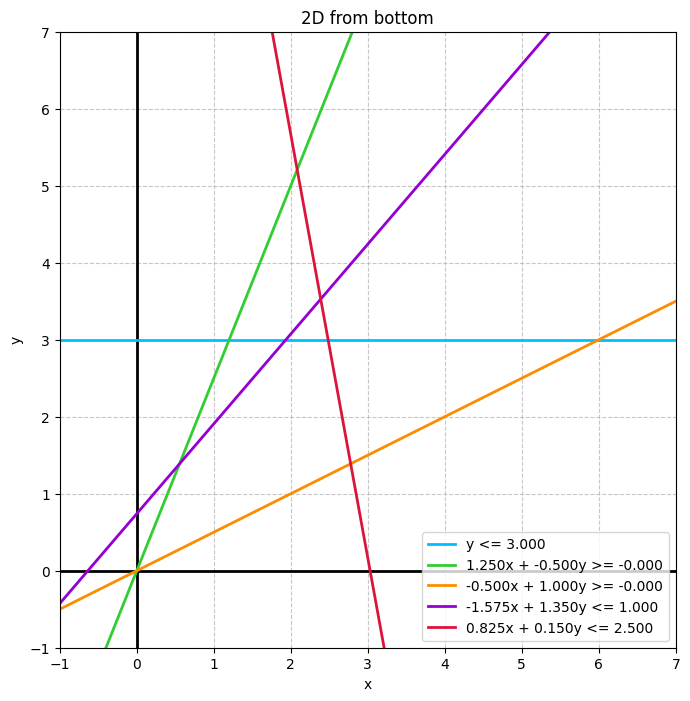

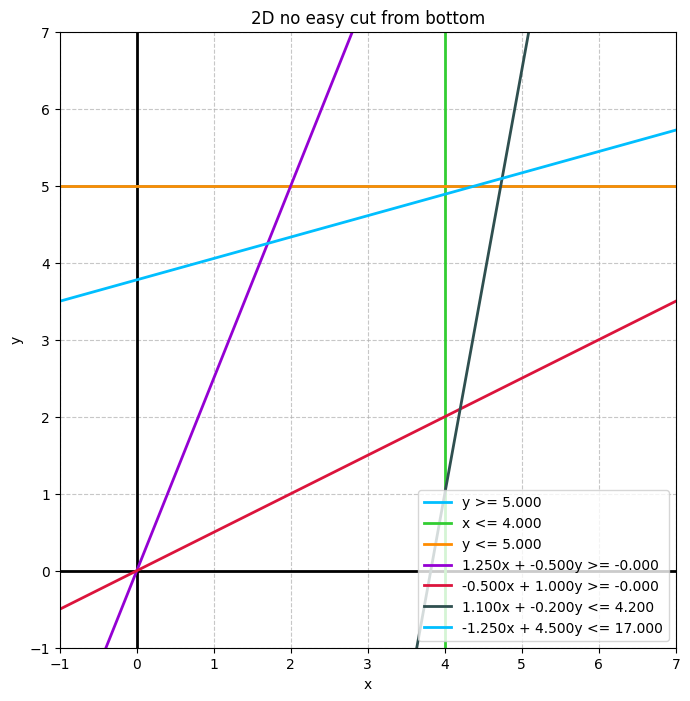

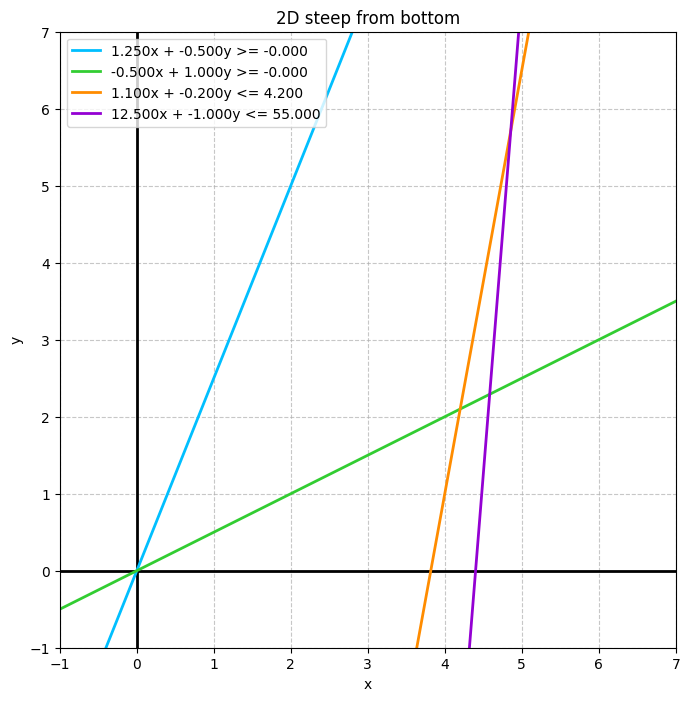

In [9]:
# simple approach: just skew it
il.reload(el)
il.reload(gu)
il.reload(pu)
il.reload(du)
il.reload(jl)

instances = el.get_instances(env)
# instances = jl.get_instances()
for instance in list(instances.values())[0:3]:
    # model = instance.as_gurobi_balas_model(use_big_m=True)  # env=env
    model = instance.as_gurobi_model()
    model.update()
    print("Running:", model.ModelName, model.NumIntVars)

    # relaxed = relax_and_shrink(model, 0.0, 0.0)
    # relaxed.params.LogToConsole = 0
    # with lt.CodeTimer("Finding relaxed optimum"):
    #     relaxed.optimize()
    # x1 = np.array([v.X for v in relaxed.getVars()]) # + [c.Slack for c in relaxed.getConstrs()])

    c = np.array(model.getAttr("Obj"))
    # U = np.array([[1, -2], [0, 1]])
    n = len(c)
    # U = np.triu(-np.ones((n, n)), k=1)
    U = np.zeros((n, n))
    variables = model.getVars()
    int_idxs = [v.index for v in variables if v.VType != gp.GRB.CONTINUOUS]
    for i, idx in enumerate(int_idxs[:-1]):
        U[idx, int_idxs[i + 1]] = -1
    np.fill_diagonal(U, 1)

    U = np.array([[1, -0.5], [0, 1]])
    U @= np.array([[1, 0], [-0.5, 1]])

    x0 = np.zeros_like(c)
    model2 = gu.apply_transform(model, U, x0)
    model2.params.LogToConsole = 0
    relaxed_vars, base_to_relaxed = gu.relax_int_or_bin_to_continuous(model2)
    for t in range(2):
        model2.optimize()
        print("\nStatus", model2.Status)
        if model2.Status == gp.GRB.OPTIMAL:
            print("Objective:", model2.ObjVal)
        cuttable_rows = list(gu.find_cuttable_rows(model2, base_to_relaxed))
        print("Cuttables:", len(cuttable_rows))
        for variable, go_smaller in cuttable_rows:
            print("   Cuttable variable:", variable.VarName, "go_smaller", go_smaller, variable.X)
            if go_smaller:
                variable.UB = np.round(variable.X - 0.501)
            else:
                # if np.isclose(variable.X % 1, 0, atol=1e-5):
                #     variable.LB = np.ceil(variable.X + 0.5)
                # else:
                variable.LB = np.round(variable.X + 0.501)
        model2.update()
    # if model2.Status == gp.GRB.OPTIMAL:
    #     print("Objective:", model2.ObjVal)
    #     x3 = np.array([v.X for v in model2.getVars()])
    #     U_inv = np.linalg.inv(U) # return it to original space
    #     x4 = U @ (x3 - (x0 - U_inv @ x0))
    #     print("X3, X4", x3, x4)  # expect x4 to be integer if transform is actually unimodular
    # else:
    #     print("Model2 not optimal:", status_lookup[model2.Status])

    if n < 4:
        A, b, c, l, u = get_A_b_c_l_u(model2)
        senses = np.array(model2.getAttr("Sense"))
        fig = pu.plot_constraints_lte(model.ModelName, A, b, l, u, senses)

In [ ]:
# simple approach: make constraints more parallel to the objective:
il.reload(el)
il.reload(gu)
il.reload(pu)
il.reload(du)
il.reload(jl)

# instances = el.get_instances(env)
instances = jl.get_instances()
for instance in list(instances.values())[7:8]:
    model = instance.as_gurobi_balas_model(use_big_m=True)  # env=env
    # model = instance.as_gurobi_model()
    model.params.LogToConsole = 0
    print("Running:", model.ModelName, model.NumIntVars)
    model.update()
    with lt.CodeTimer("Optimizing"):
        model.optimize()
    print("Found solution:", model.ObjVal)

    c = np.array(model.getAttr("Obj")).reshape(-1, 1)
    nc = np.linalg.norm(c)
    # alpha = (1 - np.cos(np.pi*0.25)) / nc #  np.array([[0.65], [0.6]])
    # alpha = np.tan(np.pi*0.75) / nc
    alpha = 0.35

    A = model.getA()  # Constraint coefficient matrix (as a scipy.sparse matrix)
    b = model.getAttr("RHS")  # Right-hand side vector

    for i in range(A.shape[0]):
        if b[i] == 0.0:
            A[i, :] /= np.abs(A[i, :].toarray()).max()
        else:
            A[i, :] /= np.abs(b[i])
            b[i] = np.sign(b[i])

    w = np.zeros((A.shape[0], 1))
    for i in range(A.shape[0]):
        row = A[i, :].toarray()  # TODO: keep it sparse
        w[i, 0] = (row @ c).item() / (np.linalg.norm(row) * nc)

    v = np.sign(w)
    warp = (sp.eye_array(A.shape[0]) - alpha * v @ w.T)
    # model2 = apply_transform(model, warp, np.zeros(c.shape[0]), normalize_Ab=True)
    # warp = np.linalg.inv(warp)
    # U = warp # / np.linalg.norm(warp, axis=0) # du.CLLL(warp)
    U = du.CLLL_Post(warp)
    A2 = U @ A
    b2 = U @ b

    model2 = gp.Model(name=f"{model.ModelName}_warped")
    model2.params.LogToConsole = 0
    x2 = []
    for var in model.getVars():
        x2.append(model2.addVar(var.LB, var.UB, var.Obj, var.VType, var.VarName))
    # x2 = gp.MVar.fromlist(x2)
    senses = np.array(model.getAttr("Sense"))
    model2.addMConstr(A2, x2, senses, b2.flatten(), name="warped")

    model2.update()
    with lt.CodeTimer("Optimizing"):
        model2.optimize()
    print("Status", model2.Status, "Found other solution:", model2.ObjVal, "\n")


    # A, b, c, l, u = get_A_b_c_l_u(model2)
    # fig = pu.plot_constraints_lte(model.ModelName, A, b, l, u)
    # du.plot_ellipse(A, b, l, u, x, fig=fig)


In [ ]:
# bring the corner in so that it's acute
# or just use the tableau so we get axis-aligned vectors

il.reload(el)
il.reload(gu)
il.reload(pu)
il.reload(du)

instances = el.get_instances(env)
# instances = jl.get_instances()
for instance in list(instances.values())[0:4]:
    # model = instance.as_gurobi_balas_model(use_big_m=True, env=env)
    model = instance.as_gurobi_model()
    print("Running:", model.ModelName)

    relaxed = relax_and_shrink(model, 0.0, 0.0)
    relaxed.optimize()
    x1 = np.array([v.X for v in relaxed.getVars()]) # + [c.Slack for c in relaxed.getConstrs()])

    niv = model.NumIntVars
    assert niv > 0
    # shrunk = relax_and_shrink(model, np.sqrt(niv), 0.1)
    # shrunk.optimize()
    # x2 = np.array([v.X for v in shrunk.getVars()])


    # get the corner vectors
    basis = gu.read_basis(relaxed)
    tableau, col_to_var_idx, negated_rows = gu.read_tableau(relaxed, basis, remove_basis_cols=True)
    gu.fix_tableau_dirs(relaxed, tableau, col_to_var_idx)
    tableau /= np.linalg.norm(tableau, axis=0)  # normalize column vectors

    # x2_bas = retreat_from_optimum_via_average_vector(tableau, x1[basis], np.sqrt(niv)* 0.45)
    # x2 = np.zeros_like(x1)
    # x2[basis] = x2_bas

    with lt.CodeTimer("Finding interior point"):
        x2 = find_interior_point(model, np.sqrt(niv) * 0.4, x1)

    direction = (x1 - x2).reshape(-1, 1)  # vectors point away by default

    # scaled = exp_scale_2(tableau, direction, eps=0.0)  # could negate dir or tableau
    scaled = tableau
    # scaled = to_U_via_LU(scaled, 0.27)
    # scaled = to_det_1(scaled)
    # orig = scaled.copy()
    # B2, U = du.lll_reduction_deepseek(scaled)
    U = scaled #  du.CLLL_Post(scaled)

    # either we make the matrix big enough for all variables, or we make it only apply to the basis variables.
    # if we do the former, I don't have to drop any columns. However, that's likely much larger and requires sparse handling.

    model2 = apply_transform(model, U, x2, basis)  # np.zeros_like(x2)
    model2.params.Presolve = 0
    model2.params.Heuristics = 0
    model2.params.Cuts = 0
    _, _ = gu.relax_int_or_bin_to_continuous(model2)
    model2.optimize()
    A, b, c, l, u = get_A_b_c_l_u(model2)
    # model2.params.LogToConsole = 0
    # model2.optimize()
    # x3 = np.array([v.X for v in model2.getVars()])
    # # return it to original space:
    # U_inv = np.linalg.inv(U)
    # x4 = U_inv @ (x3 - (x2 - U @ x2))
    # print("X3, X4", x3, x4)

    senses = np.array(model2.getAttr("Sense"))
    fig = pu.plot_constraints_lte(model.ModelName, A, b, l, u, senses, points=[x2[:2]])
    du.plot_ellipse(A, b, l, u, x2, fig=fig)

    assert model2.Status == gp.GRB.OPTIMAL
    basis = gu.read_basis(model2)
    tableau, col_to_var_idx, negated_rows = gu.read_tableau(model2, basis, remove_basis_cols=True)
    gu.fix_tableau_dirs(model2, tableau, col_to_var_idx)

    # x=U(y - x0) + x0 so y=U_inv(x - x0) + x0
    # so for y_i <= 2, we have (U_inv(x - x0) + x0)_i <= 2
    x = gp.MVar.fromlist(relaxed.getVars())
    y = model2._U_inv @ (x - x2) + x2
    for i, row in zip(basis, -tableau):
        # we can only cut vars that are supposed to be integers, but how can we tell which those are?
        if i >= model.NumVars:
            continue
        if np.all(row > -model2.params.IntFeasTol):
            relaxed.addConstr(y[i] >= np.ceil(model2._y_vars[i].X))
        elif np.all(row < model2.params.IntFeasTol):
            relaxed.addConstr(y[i] <= np.floor(model2._y_vars[i].X))

    A, b, c, l, u = get_A_b_c_l_u(relaxed)
    senses = np.array(relaxed.getAttr("Sense"))
    fig = pu.plot_constraints_lte(relaxed.ModelName, A, b, l, u, senses, points=[x2[:2]])
    # du.plot_ellipse(A, b, l, u, x2, fig=fig)

In [ ]:
# make the Dikin ellipsoid be round:

import ntl_wrapper as ntl
il.reload(ntl)
il.reload(el)
il.reload(gu)
il.reload(pu)
il.reload(du)

# instances = el.get_instances(env)
instances = jl.get_instances()

for instance in list(instances.values())[0:4]:
    model = instance.as_gurobi_balas_model(use_big_m=True, env=env)
    # model = instance.as_gurobi_model()
    model.update()
    print("Running:", model.ModelName)

    niv = model.NumIntVars
    assert niv > 0

    relaxed = relax_and_shrink(model, 0.0, 0.0)
    relaxed.optimize()
    x1 = np.array([v.X for v in relaxed.getVars()]) # + [c.Slack for c in relaxed.getConstrs()])

    # shrunk = relax_and_shrink(model, np.sqrt(niv), 0.45)
    # shrunk.params.LogToConsole = 0
    # shrunk.optimize()
    # x2 = np.array([v.X for v in shrunk.getVars()])
    with lt.CodeTimer("Finding interior point"):
        x2 = find_interior_point(model, np.sqrt(niv) * 0.4, x1)

    gu.standardize_gt_to_lt(model)
    A, b, c, l, u = get_A_b_c_l_u(model)
    
    H = du.compute_H(A, b, l, u, x2)  # h.shape == (n, n)
    H = H.toarray()  # for small projects
    import scipy.linalg as spl
    H2 = spl.sqrtm(H)  # TODO: add a more efficient eigenvalue decomposition for the sqrt
    # U = to_U_via_SNF(H2)

    H2 = np.linalg.inv(H2)
    # U = H2 # makes nice pretty circles
    # U = to_U_via_LU(H2, mult=1)
    # U = to_U_via_SNF(H2, 2)
    # U = du.CLLL_Pre(H2)  # modifies H2
    # U = du.CLLL_Post(H2, 0.7)
    rnk, det, U = ntl.lll(np.round(H2 * 1000).astype(np.int64), 99, 100)
    U = np.linalg.inv(U.T)
    
    # print("Determinant:", np.linalg.det(U), ", U:", U)

    model2 = gu.apply_transform(model, U, x2, mult=1)
    A, b, c, l, u = get_A_b_c_l_u(model2)

    model2.params.LogToConsole = 0
    model2.optimize()
    if model2.Status == gp.GRB.OPTIMAL:
        x3 = np.array([v.X for v in model2.getVars()])
        # return it to original space:
        U_inv = np.linalg.inv(U)
        x4 = U @ (x3 - (x2 - U_inv @ x2))
        print(model2.ObjVal, instance.score, "X3, X4", x3, x4)  # expect x4 to be integer if transform is actually unimodular
    else:
        print("Model2 not optimal:", model2.Status)

    if model.NumIntVars < 4:
        senses = np.array(model2.getAttr("Sense"))
        fig = pu.plot_constraints_lte(model.ModelName, A, b, l, u, senses, points=[x2[:2]])
        du.plot_ellipse(A, b, l, u, x2, fig=fig)


Running: abz2
   Relaxed 8 variables on abz2_copy
Interior point found: [  0.18774534  68.45325734   0.18774534  72.45325734   0.18774534
   0.20003189   0.18774534   0.18774534   0.18774534   0.65243656
   0.18774534   0.18774534 162.71876935] r 0.18774533797910486
Code block 'Finding interior point' took: 39.82015 ms
   Negated 8 constraints on abz2
Set parameter LogToConsole to value 0
162.07776666332455 True X3, X4 [ 2.37641937e-03  6.83587585e+01  0.00000000e+00  7.22655120e+01
  1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00
 -0.00000000e+00  1.00000000e+00 -0.00000000e+00 -0.00000000e+00
  1.62453257e+02] [-1.00339922e-09  6.80777667e+01  5.35308779e-01  7.26130754e+01
  6.00531042e-10  1.46629675e-02  0.00000000e+00  1.00000000e+00
  9.87713453e-01  5.57937748e-01  1.00000000e+00  1.00000000e+00
  1.62077767e+02]
Running: abz3a
   Relaxed 18 variables on abz3a_copy
Interior point found: [  0.23276875  68.56195347   0.23276876  72.5619535    0.23276876
  61.56195

Define $x=Uy + x_0$. Then:

The variable bounds transformation: $U^{-1} (\ell_x - x_0) \leq y \leq U^{-1} (u_x - x_0)$

Constraints: $A U y \leq b - A x_0$

Objective: $(c^T U) y + c^T x_0 + c_0$

In [ ]:
import jsplib_loader as jl
instances = jl.get_instances()
instance = instances["abz5"]
model = instance.as_gurobi_model()
print("Running:", model.ModelName)

shrunk = relax_and_shrink(model, np.sqrt(niv), 0.3)
shrunk.optimize()
x2 = np.array([v.X for v in shrunk.getVars()])

gu.standardize_gt_to_lt(model)
A, b, c, l, u = get_A_b_c_l_u(model)

H = du.compute_H(A, b, l, u, x2)
import scipy.linalg as spl
R = spl.sqrtm(H.toarray())  # TODO: add a more efficient eigenvalue decomposition for the sqrt
R = np.round(R * 1000)
U = du.CLLL(R)  # modifies H2
print("Determinant:", np.linalg.det(U))

model2 = apply_transform(model, U, x2)
model2.optimize()